# Predicción del abandono de clientes de Netflix

**Proyecto final de Minería de Datos**  
**Caso de estudio empresarial:** análisis de abandono (*customer churn*) y nivel de interacción de clientes.

Este cuaderno desarrolla un proceso completo de minería de datos: definición del problema, exploración, preprocesamiento, modelado, comparación de algoritmos, evaluación e interpretación orientada a la toma de decisiones.

## 1. Definición del problema

La pérdida de clientes afecta los ingresos y eleva los costos de adquisición. El propósito del estudio es construir un modelo de clasificación binaria que estime si un cliente abandonará el servicio.

### Objetivo general

Desarrollar y evaluar modelos predictivos capaces de clasificar a los clientes según su probabilidad de abandono.

### Objetivos específicos

- Explorar las características demográficas, de suscripción y consumo.
- Verificar la calidad de los datos e identificar valores faltantes, duplicados y posibles valores atípicos.
- Transformar las variables categóricas y escalar las variables numéricas cuando corresponda.
- Comparar regresión logística, árbol de decisión y Random Forest.
- Seleccionar el modelo mediante F1 y ROC-AUC, sin depender únicamente de la exactitud.

**Variable objetivo:** `churned`, donde 0 significa que el cliente permanece y 1 que abandona.

## 2. Librerías y carga de datos

In [4]:
# Librerías principales
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

# Busca el archivo tanto en Colab como en la carpeta data del repositorio.
rutas = ["netflix_customer_churn.csv", "data/netflix_customer_churn.csv"]
ruta_csv = next((ruta for ruta in rutas if os.path.exists(ruta)), None)

if ruta_csv is None:
    from google.colab import files
    print("Seleccione el archivo netflix_customer_churn.csv")
    files.upload()
    ruta_csv = "netflix_customer_churn.csv"

df = pd.read_csv(ruta_csv)
print(f"Archivo cargado: {ruta_csv}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(df.head())

Archivo cargado: netflix_customer_churn.csv
Filas: 5,000 | Columnas: 14


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## 3. Exploración y calidad de los datos

In [5]:
print("Tipos de datos y valores no nulos:\n")
df.info()

resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

print(f"\nRegistros duplicados: {df.duplicated().sum()}")
display(resumen_calidad)

Tipos de datos y valores no nulos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: f

,tipo,nulos,porcentaje_nulos,valores_unicos
customer_id,object,0,0.0,5000
age,int64,0,0.0,53
gender,object,0,0.0,3
subscription_type,object,0,0.0,3
watch_hours,float64,0,0.0,2343
last_login_days,int64,0,0.0,61
region,object,0,0.0,6
device,object,0,0.0,5
monthly_fee,float64,0,0.0,3
churned,int64,0,0.0,2


In [6]:
# Estadísticos descriptivos de las variables numéricas
display(df.describe().T.round(2))

# Categorías disponibles en las variables de texto
columnas_categoricas_originales = df.select_dtypes(include="object").columns
for columna in columnas_categoricas_originales:
    if columna != "customer_id":
        print(f"\n{columna}: {sorted(df[columna].dropna().unique().tolist())}")

,count,mean,std,min,25%,50%,75%,max
age,5000.0,43.85,15.50,18.00,30.00,44.00,58.00,70.00
watch_hours,5000.0,11.65,12.01,0.01,3.34,8.00,16.03,110.40
last_login_days,5000.0,30.09,17.54,0.00,15.00,30.00,45.00,60.00
monthly_fee,5000.0,13.68,3.69,8.99,8.99,13.99,17.99,17.99
churned,5000.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00
number_of_profiles,5000.0,3.02,1.42,1.00,2.00,3.00,4.00,5.00
avg_watch_time_per_day,5000.0,0.87,2.62,0.00,0.11,0.29,0.72,98.42



gender: ['Female', 'Male', 'Other']

subscription_type: ['Basic', 'Premium', 'Standard']

region: ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

device: ['Desktop', 'Laptop', 'Mobile', 'TV', 'Tablet']

payment_method: ['Credit Card', 'Crypto', 'Debit Card', 'Gift Card', 'PayPal']

favorite_genre: ['Action', 'Comedy', 'Documentary', 'Drama', 'Horror', 'Romance', 'Sci-Fi']


### Interpretación inicial

La edad mínima válida del conjunto es 18 años. Una edad de 10 años sería inconsistente con el contexto comercial porque un menor normalmente no sería el titular contractual de una suscripción. Por ello, los rangos se revisan con criterios del negocio y no solamente con reglas estadísticas.

In [7]:
# Validaciones de rangos y balance de la variable objetivo
validaciones = pd.DataFrame({
    "variable": ["age", "watch_hours", "last_login_days", "monthly_fee", "number_of_profiles", "avg_watch_time_per_day"],
    "mínimo": [df[c].min() for c in ["age", "watch_hours", "last_login_days", "monthly_fee", "number_of_profiles", "avg_watch_time_per_day"]],
    "media": [df[c].mean() for c in ["age", "watch_hours", "last_login_days", "monthly_fee", "number_of_profiles", "avg_watch_time_per_day"]],
    "máximo": [df[c].max() for c in ["age", "watch_hours", "last_login_days", "monthly_fee", "number_of_profiles", "avg_watch_time_per_day"]]
})
display(validaciones.round(2))

distribucion_objetivo = df["churned"].value_counts().sort_index().rename(index={0: "Permanece", 1: "Abandona"})
display(pd.DataFrame({
    "cantidad": distribucion_objetivo,
    "porcentaje": (distribucion_objetivo / len(df) * 100).round(2)
}))

,variable,mínimo,media,máximo
0,age,18.00,43.85,70.00
1,watch_hours,0.01,11.65,110.40
2,last_login_days,0.00,30.09,60.00
3,monthly_fee,8.99,13.68,17.99
4,number_of_profiles,1.00,3.02,5.00
5,avg_watch_time_per_day,0.00,0.87,98.42


,cantidad,porcentaje
churned,,
Permanece,2485,49.7
Abandona,2515,50.3


## 4. Visualizaciones descriptivas

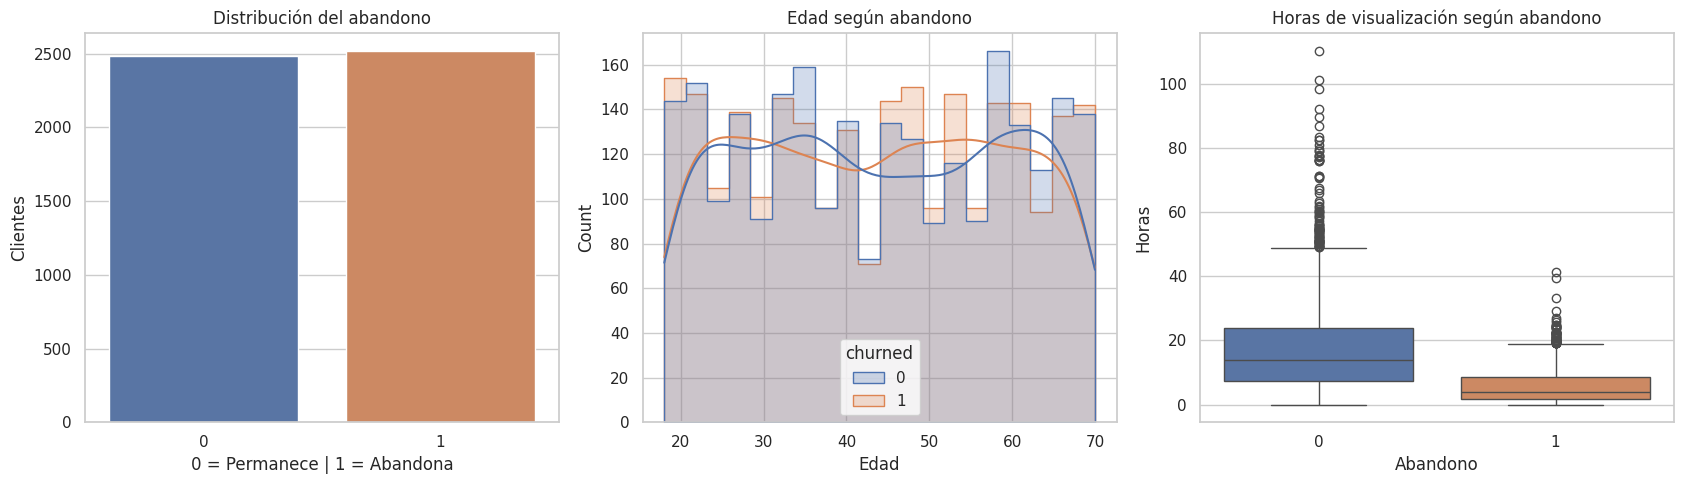

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.countplot(data=df, x="churned", hue="churned", legend=False, ax=axes[0])
axes[0].set_title("Distribución del abandono")
axes[0].set_xlabel("0 = Permanece | 1 = Abandona")
axes[0].set_ylabel("Clientes")

sns.histplot(data=df, x="age", hue="churned", bins=20, kde=True, element="step", ax=axes[1])
axes[1].set_title("Edad según abandono")
axes[1].set_xlabel("Edad")

sns.boxplot(data=df, x="churned", y="watch_hours", hue="churned", legend=False, ax=axes[2])
axes[2].set_title("Horas de visualización según abandono")
axes[2].set_xlabel("Abandono")
axes[2].set_ylabel("Horas")

plt.tight_layout()
plt.show()

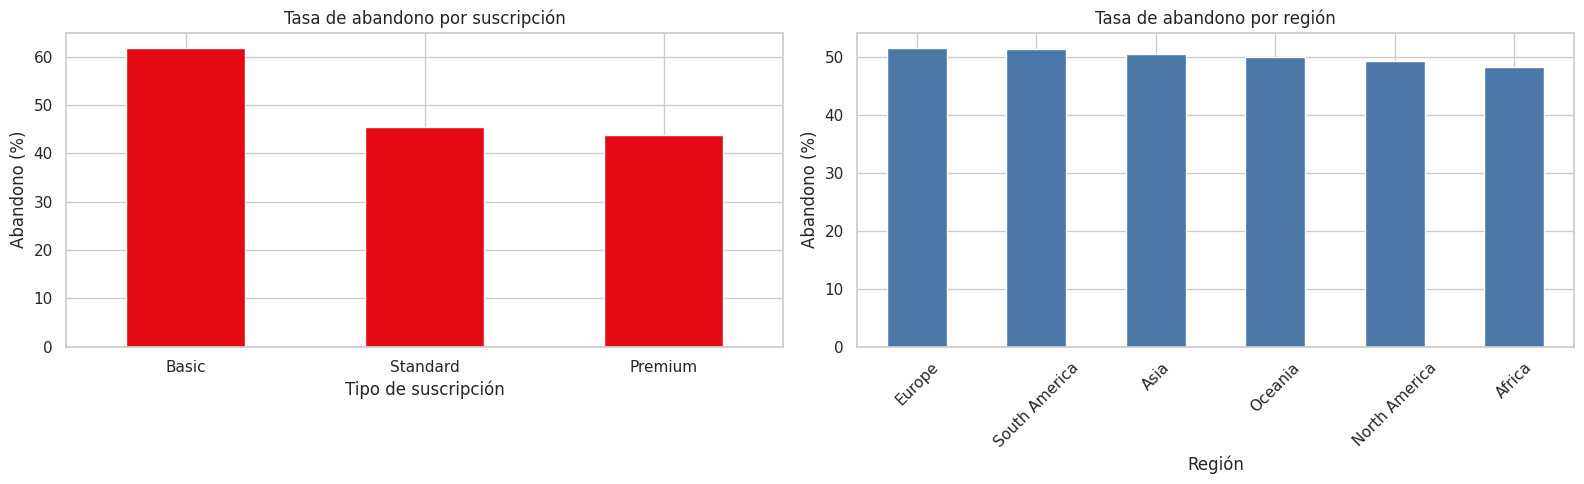

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

tasa_suscripcion = df.groupby("subscription_type")["churned"].mean().sort_values(ascending=False) * 100
tasa_suscripcion.plot(kind="bar", color="#E50914", ax=axes[0])
axes[0].set_title("Tasa de abandono por suscripción")
axes[0].set_ylabel("Abandono (%)")
axes[0].set_xlabel("Tipo de suscripción")
axes[0].tick_params(axis="x", rotation=0)

tasa_region = df.groupby("region")["churned"].mean().sort_values(ascending=False) * 100
tasa_region.plot(kind="bar", color="#4C78A8", ax=axes[1])
axes[1].set_title("Tasa de abandono por región")
axes[1].set_ylabel("Abandono (%)")
axes[1].set_xlabel("Región")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

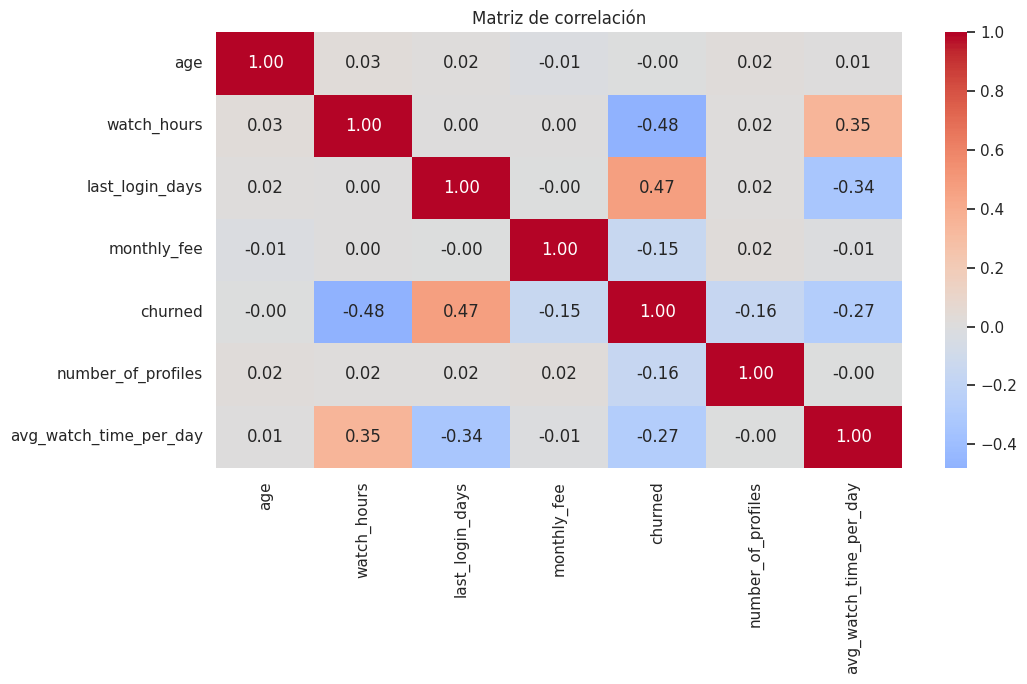

In [10]:
# Correlación entre variables numéricas
numericas_para_correlacion = df.select_dtypes(include=np.number)
plt.figure(figsize=(11, 7))
sns.heatmap(numericas_para_correlacion.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 5. Preprocesamiento

`customer_id` se excluye porque identifica al cliente, pero no representa un comportamiento útil para generalizar. Las variables categóricas se transforman mediante *one-hot encoding*: cada categoría se convierte en una columna binaria. El 1 solo indica presencia de la categoría; no significa que sea mejor que 0.

Las variables numéricas se imputan con la mediana y se estandarizan. `StandardScaler` transforma cada variable para que tenga aproximadamente media 0 y desviación estándar 1, evitando que una escala numérica domine a las demás. Todo el procesamiento se incorpora a un `Pipeline` para impedir fuga de información.

In [11]:
# Separación entre características y variable objetivo
X = df.drop(columns=["churned", "customer_id"])
y = df["churned"].astype(int)

columnas_numericas = X.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:", columnas_numericas)
print("Variables categóricas:", columnas_categoricas)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} registros ({len(X_train)/len(X)*100:.0f}%)")
print(f"Prueba: {X_test.shape[0]} registros ({len(X_test)/len(X)*100:.0f}%)")

Variables numéricas: ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']
Variables categóricas: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
Entrenamiento: 4000 registros (80%)
Prueba: 1000 registros (20%)


In [12]:
pipeline_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(transformers=[
    ("num", pipeline_numerico, columnas_numericas),
    ("cat", pipeline_categorico, columnas_categoricas)
])

print("Preprocesamiento configurado correctamente.")

Preprocesamiento configurado correctamente.


## 6. Modelado y comparación

Se comparan tres enfoques:

1. **Regresión logística:** modelo lineal interpretable y línea base.
2. **Árbol de decisión:** aprende reglas no lineales fáciles de explicar.
3. **Random Forest:** ensamble de árboles que reduce la variabilidad de un árbol individual.

La selección se realiza principalmente con F1 y ROC-AUC. F1 es la media armónica entre precisión y sensibilidad, y resulta útil cuando interesa equilibrar falsos positivos y falsos negativos.

In [13]:
modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    )
}

resultados = []
pipelines_entrenados = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ])
    pipeline.fit(X_train, y_train)
    prediccion = pipeline.predict(X_test)
    probabilidad = pipeline.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_test, prediccion),
        "Precisión": precision_score(y_test, prediccion, zero_division=0),
        "Sensibilidad": recall_score(y_test, prediccion, zero_division=0),
        "F1": f1_score(y_test, prediccion, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilidad)
    })
    pipelines_entrenados[nombre] = pipeline

tabla_resultados = pd.DataFrame(resultados).set_index("Modelo").sort_values("F1", ascending=False)
display(tabla_resultados.style.format("{:.4f}").background_gradient(cmap="Blues"))

,Exactitud,Precisión,Sensibilidad,F1,ROC-AUC
Modelo,,,,,
Random Forest,0.9770,0.9762,0.9781,0.9772,0.9966
Árbol de decisión,0.9490,0.9708,0.9264,0.9481,0.9877
Regresión logística,0.8870,0.8750,0.9046,0.8895,0.9659


In [14]:
# Validación cruzada sobre el conjunto de entrenamiento
metricas_cv = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}
resultados_cv = []

for nombre, pipeline in pipelines_entrenados.items():
    cv = cross_validate(pipeline, X_train, y_train, cv=5, scoring=metricas_cv, n_jobs=1)
    resultados_cv.append({
        "Modelo": nombre,
        "Exactitud CV": cv["test_accuracy"].mean(),
        "F1 CV": cv["test_f1"].mean(),
        "ROC-AUC CV": cv["test_roc_auc"].mean(),
        "Desviación F1": cv["test_f1"].std()
    })

tabla_cv = pd.DataFrame(resultados_cv).set_index("Modelo").sort_values("F1 CV", ascending=False)
display(tabla_cv.style.format("{:.4f}").background_gradient(cmap="Greens"))

,Exactitud CV,F1 CV,ROC-AUC CV,Desviación F1
Modelo,,,,
Random Forest,0.9667,0.9669,0.9961,0.0053
Árbol de decisión,0.9492,0.9479,0.9855,0.0084
Regresión logística,0.8942,0.8953,0.9662,0.0054


## 7. Evaluación detallada del mejor modelo

Mejor modelo según F1 en prueba: Random Forest

Reporte de clasificación:

              precision    recall  f1-score   support

   Permanece     0.9778    0.9759    0.9768       497
    Abandona     0.9762    0.9781    0.9772       503

    accuracy                         0.9770      1000
   macro avg     0.9770    0.9770    0.9770      1000
weighted avg     0.9770    0.9770    0.9770      1000



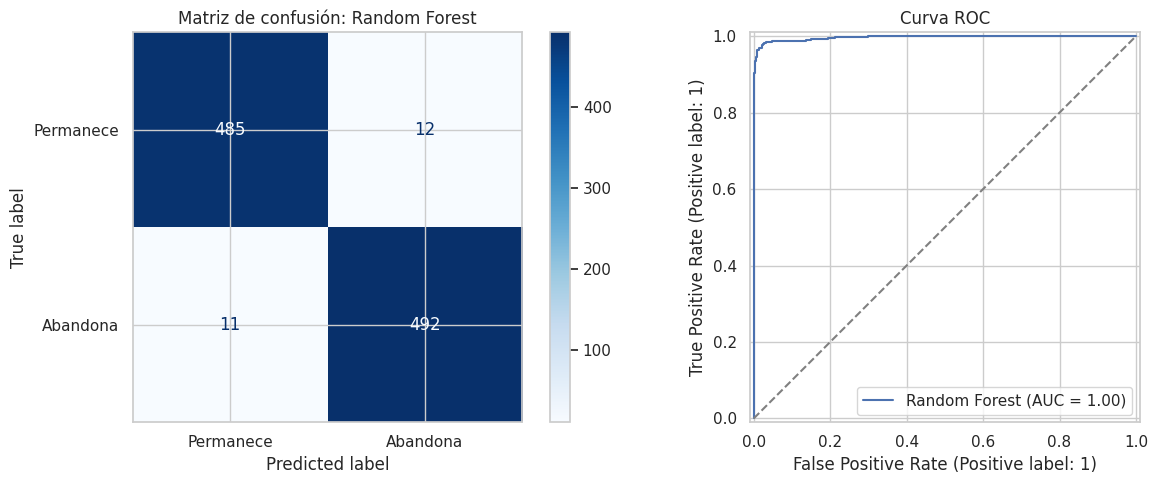

In [15]:
mejor_nombre = tabla_resultados.index[0]
mejor_modelo = pipelines_entrenados[mejor_nombre]

y_pred = mejor_modelo.predict(X_test)
y_prob = mejor_modelo.predict_proba(X_test)[:, 1]

print("Mejor modelo según F1 en prueba:", mejor_nombre)
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["Permanece", "Abandona"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Permanece", "Abandona"],
    cmap="Blues", values_format="d", ax=axes[0]
)
axes[0].set_title(f"Matriz de confusión: {mejor_nombre}")

RocCurveDisplay.from_predictions(y_test, y_prob, name=mejor_nombre, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Curva ROC")

plt.tight_layout()
plt.show()

### Cómo interpretar la matriz de confusión

- **Verdadero positivo:** cliente que abandonó y fue identificado correctamente.
- **Verdadero negativo:** cliente que permaneció y fue identificado correctamente.
- **Falso positivo:** se predice abandono, pero el cliente permanece; puede generar una acción de retención innecesaria.
- **Falso negativo:** se predice permanencia, pero el cliente abandona; representa una oportunidad de retención perdida.

## 8. Variables influyentes

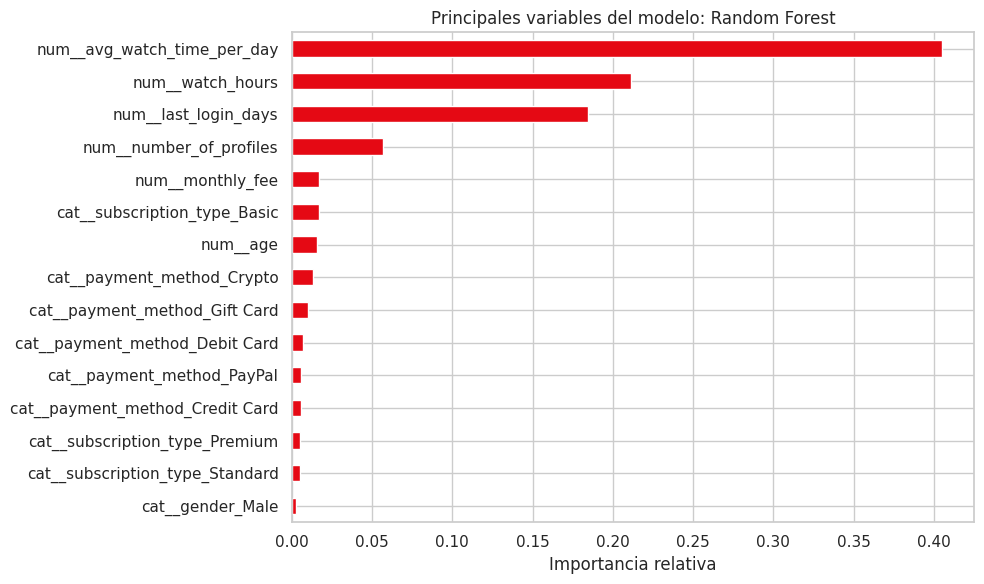

,importancia
num__avg_watch_time_per_day,0.404703
num__watch_hours,0.211182
num__last_login_days,0.184796
num__number_of_profiles,0.056558
num__monthly_fee,0.017124
cat__subscription_type_Basic,0.016873
num__age,0.015907
cat__payment_method_Crypto,0.013351
cat__payment_method_Gift Card,0.010382
cat__payment_method_Debit Card,0.007158


In [16]:
# Importancia disponible si el mejor modelo se basa en árboles
modelo_final = mejor_modelo.named_steps["modelo"]
preprocesamiento_final = mejor_modelo.named_steps["preprocesamiento"]
nombres_variables = preprocesamiento_final.get_feature_names_out()

if hasattr(modelo_final, "feature_importances_"):
    importancia = pd.Series(modelo_final.feature_importances_, index=nombres_variables)
elif hasattr(modelo_final, "coef_"):
    importancia = pd.Series(np.abs(modelo_final.coef_[0]), index=nombres_variables)
else:
    importancia = None

if importancia is not None:
    top = importancia.sort_values(ascending=False).head(15).sort_values()
    plt.figure(figsize=(10, 6))
    top.plot(kind="barh", color="#E50914")
    plt.title(f"Principales variables del modelo: {mejor_nombre}")
    plt.xlabel("Importancia relativa")
    plt.tight_layout()
    plt.show()
    display(importancia.sort_values(ascending=False).head(15).to_frame("importancia"))

## 9. Análisis crítico y utilidad empresarial

La evaluación debe interpretarse con prudencia. Un modelo no obtiene 100 % por utilizar inteligencia artificial; su desempeño depende de la relación real entre las variables disponibles y el abandono. Si F1 o ROC-AUC se aproximan a 0,50, las características del conjunto no contienen una señal predictiva suficiente y el resultado es cercano al azar.

En un escenario empresarial sería recomendable añadir variables como antigüedad del cliente, cambios recientes del plan, errores de reproducción, contactos con soporte, variación mensual del consumo, historial de pagos y respuesta a promociones. El modelo puede utilizarse para priorizar campañas de retención, pero no debería cancelar cuentas ni tomar decisiones automáticas perjudiciales.

Las predicciones son asociaciones estadísticas y no prueban causalidad. También se debe vigilar la equidad del modelo y evitar acciones discriminatorias basadas en características sensibles.

## 10. Guardado del modelo y predicción de un caso nuevo

In [17]:
# Guardado del pipeline completo: preprocesamiento + modelo
nombre_archivo_modelo = "mejor_modelo_netflix.joblib"
joblib.dump(mejor_modelo, nombre_archivo_modelo)
print(f"Modelo guardado como: {nombre_archivo_modelo}")

# Caso ilustrativo con la misma estructura de X
nuevo_cliente = X.iloc[[0]].copy()
prediccion_nueva = mejor_modelo.predict(nuevo_cliente)[0]
probabilidad_nueva = mejor_modelo.predict_proba(nuevo_cliente)[0, 1]

print("\nPredicción del caso de ejemplo:", "Abandona" if prediccion_nueva == 1 else "Permanece")
print(f"Probabilidad estimada de abandono: {probabilidad_nueva:.2%}")
display(nuevo_cliente)

Modelo guardado como: mejor_modelo_netflix.joblib

Predicción del caso de ejemplo: Abandona
Probabilidad estimada de abandono: 61.08%


,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,Gift Card,1,0.49,Action


## 11. Conclusiones

Se desarrolló un flujo reproducible de minería de datos que integra exploración, transformación, entrenamiento y evaluación. La comparación de varios algoritmos permite justificar la selección del modelo con evidencia y evita asumir que una técnica funciona mejor en todos los conjuntos de datos.

F1 equilibra precisión y sensibilidad, mientras ROC-AUC evalúa la capacidad de ordenar clientes por riesgo a través de distintos umbrales. El desempeño obtenido debe comunicarse sin exageraciones: un resultado limitado puede revelar que hacen falta variables más informativas, no necesariamente que el algoritmo esté mal implementado.

Como siguiente etapa se propone desplegar el pipeline seleccionado en una aplicación Streamlit, registrar predicciones de prueba y documentar el proyecto en GitHub.

## 12. Descarga de entregables desde Google Colab

In [19]:
# Ejecute esta celda en Colab para descargar el modelo entrenado.
try:
    from google.colab import files
    files.download("mejor_modelo_netflix.joblib")
except ImportError:
    print("La descarga automática está disponible cuando el cuaderno se ejecuta en Google Colab.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>